# Assessment | Statistical Evaluation Mini-Project

Work through the four tasks below using the **Auto MPG** dataset. Each task has its own section with scaffolding cells — add as many code and markdown cells as you need.

## Setup

Run the cell below to load the dataset and verify everything is working.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

SEED = 42
np.random.seed(SEED)

mpg = sns.load_dataset("mpg").dropna()

print(f"Rows: {len(mpg)}, Columns: {mpg.shape[1]}")
print(f"Origin groups: {mpg['origin'].unique().tolist()}")
mpg.head()

Rows: 392, Columns: 9
Origin groups: ['usa', 'japan', 'europe']


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [2]:
mpg.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


---
## Task 1 — Correlation Analysis

1. Choose at least three pairs of numeric variables and compute Pearson and Spearman correlations.
2. Test each for significance (report p-values).
3. Create a correlation heatmap and at least two scatter plots with regression lines.
4. Explain when Pearson vs. Spearman is more appropriate, using your results as examples.

In [3]:
# Correlation coefficients and p-values
numeric_vars = ['mpg', 'weight', 'displacement', 'horsepower']
results = []

for i in range(len(numeric_vars)):
    for j in range(i + 1, len(numeric_vars)):
        v1, v2 = numeric_vars[i], numeric_vars[j]
        
        pearson_r, p_pearson = stats.pearsonr(mpg[v1], mpg[v2])
        spearman_r, p_spearman = stats.spearmanr(mpg[v1], mpg[v2])
        
        results.append({
            "Pair": f"{v1} vs {v2}",
            "Pearson R": round(pearson_r, 4),
            "P-Value (P)": f"{p_pearson:.4e}",
            "Spearman R": round(spearman_r, 4),
            "P-Value (S)": f"{p_spearman:.4e}"
        })

correlation_df = pd.DataFrame(results)
print(correlation_df)

                         Pair  Pearson R  P-Value (P)  Spearman R  P-Value (S)
0               mpg vs weight    -0.8322  6.0153e-102     -0.8756  2.6624e-125
1         mpg vs displacement    -0.8051   1.6606e-90     -0.8552  2.1958e-113
2           mpg vs horsepower    -0.7784   7.0320e-81     -0.8536  1.6194e-112
3      weight vs displacement     0.9330  3.4891e-175      0.9456  2.4632e-192
4        weight vs horsepower     0.8645  1.3643e-118      0.8788  2.1827e-127
5  displacement vs horsepower     0.8973  1.5109e-140      0.8762  1.1267e-125


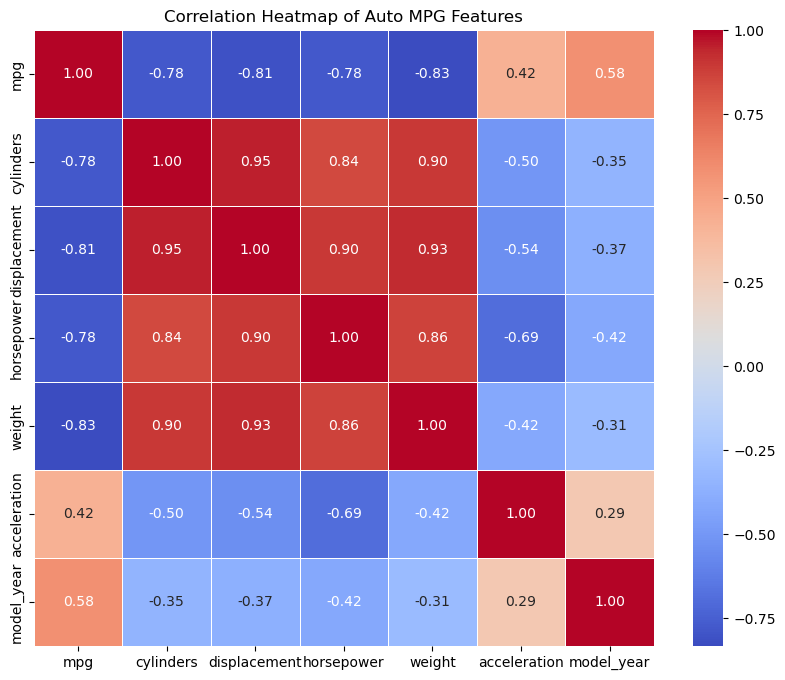

In [4]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
corr_matrix = mpg.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Auto MPG Features")
plt.show()

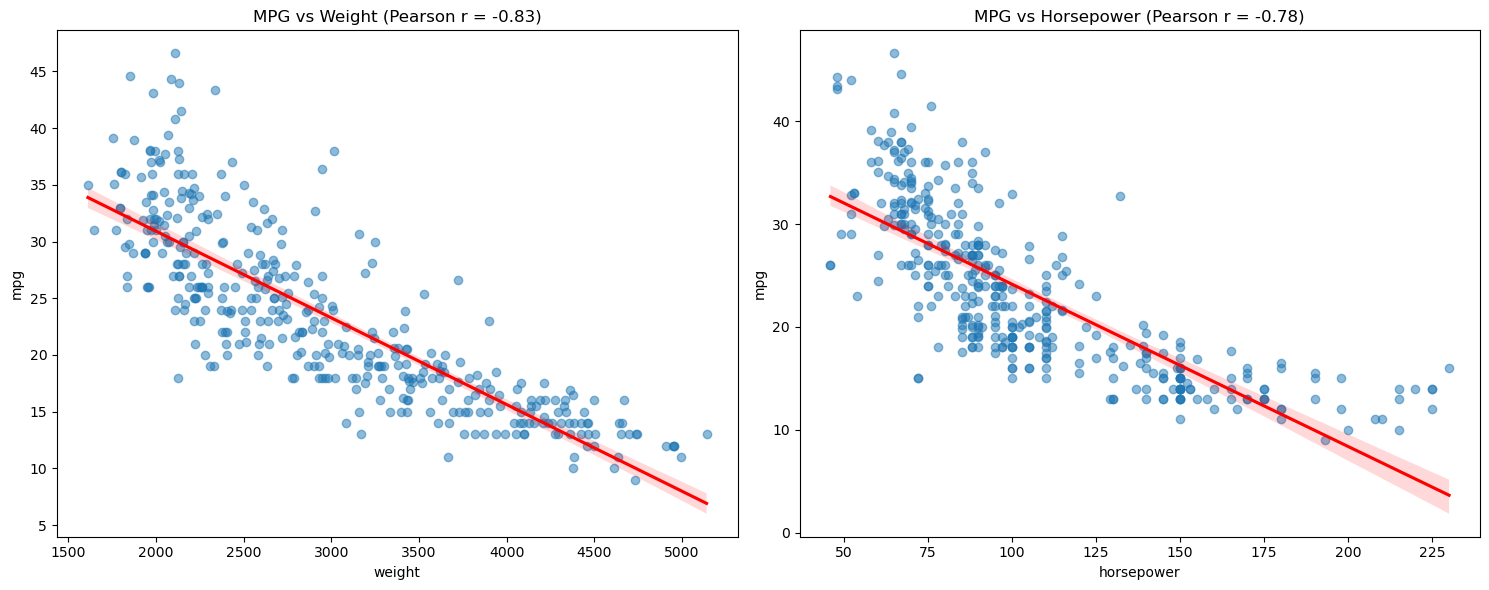

In [5]:
# Scatter plots with regression lines
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: mpg vs weight 
sns.regplot(data=mpg, x='weight', y='mpg', ax=axes[0], 
            line_kws={"color": "red"}, scatter_kws={'alpha':0.5})
r_p = correlation_df.loc[correlation_df['Pair'] == 'mpg vs weight', 'Pearson R'].values[0]
axes[0].set_title(f"MPG vs Weight (Pearson r = {r_p:.2f})")

# Plot 2: mpg vs horsepower 
sns.regplot(data=mpg, x='horsepower', y='mpg', ax=axes[1], 
            line_kws={"color": "red"}, scatter_kws={'alpha':0.5}, order=1)
r_p2 = correlation_df.loc[correlation_df['Pair'] == 'mpg vs horsepower', 'Pearson R'].values[0]
axes[1].set_title(f"MPG vs Horsepower (Pearson r = {r_p2:.2f})")

plt.tight_layout()
plt.show()
plt.show()

### Interpretation

*When is Pearson vs. Spearman more appropriate? Use your results as examples.*

> Pearson correlation works best when variables follow a straight line. In our **mpg vs. weight** plot, the data points cluster evenly along the red line, resulting in a high Pearson score of **-0.83**.
> 
> However, for **mpg vs. horsepower**, we see a slight curve—mpg drops quickly at first and then levels off. Because the Spearman method looks at the "rank" or order of the data rather than a straight line, it handles this curvature much better than Pearson. This is also why the red "confidence shade" on the horsepower plot gets much wider at the end: there is more uncertainty in trying to fit a straight line to data that naturally wants to curve.

---
## Task 2 — Group Comparisons

1. Choose a numeric variable and visualize its distribution by origin (box/violin plot).
2. Check ANOVA assumptions: Shapiro-Wilk (normality) and Levene's test (equal variances).
3. Run one-way ANOVA — report F-statistic, p-value, and eta-squared.
4. If significant, run Tukey's HSD and state which groups differ.

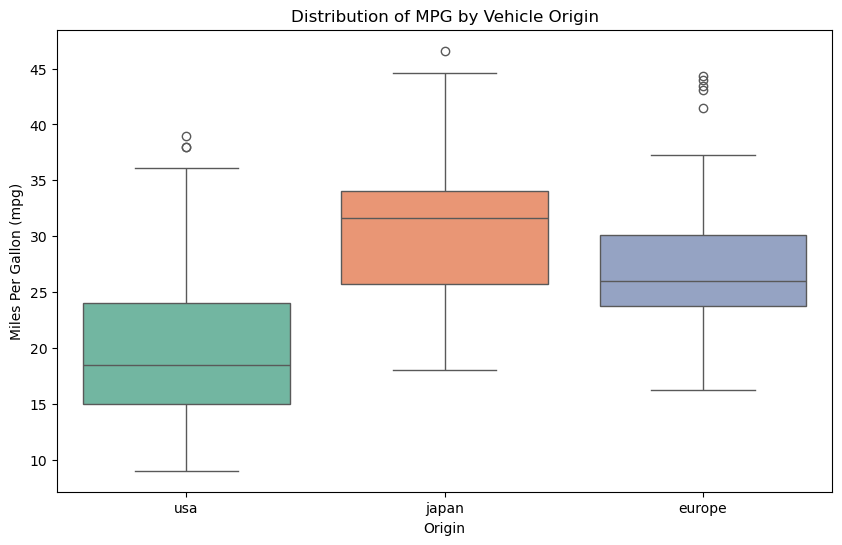

In [6]:
# Distribution visualization by origin
plt.figure(figsize=(10, 6))
sns.boxplot(data=mpg, x='origin', y='mpg', hue='origin', palette='Set2', legend=False)
plt.title("Distribution of MPG by Vehicle Origin")
plt.xlabel("Origin")
plt.ylabel("Miles Per Gallon (mpg)")
plt.show()

In [7]:
# Assumption checks: Shapiro-Wilk + Levene's test
origins = mpg['origin'].unique()
normality_results = []

print("--- Shapiro-Wilk Test (Normality) ---")
for origin in origins:
    group_data = mpg[mpg['origin'] == origin]['mpg']
    stat, p = stats.shapiro(group_data)
    normality_results.append((origin, stat, p))
    print(f"{origin.capitalize()}: W={stat:.4f}, p={p:.4f}")

print("\n--- Levene's Test (Homogeneity of Variance) ---")
groups = [mpg[mpg['origin'] == o]['mpg'] for o in origins]
l_stat, l_p = stats.levene(*groups)
print(f"Levene's Statistic: {l_stat:.4f}, p-value: {l_p:.4f}")

--- Shapiro-Wilk Test (Normality) ---
Usa: W=0.9337, p=0.0000
Japan: W=0.9797, p=0.2420
Europe: W=0.9462, p=0.0054

--- Levene's Test (Homogeneity of Variance) ---
Levene's Statistic: 0.0861, p-value: 0.9175


In [8]:
# One-way ANOVA
f_stat, p_val = stats.f_oneway(*groups)

print(f"ANOVA Results: F={f_stat:.4f}, p={p_val:.4e}")

ANOVA Results: F=96.6015, p=8.6738e-35


In [9]:
# Calculating Eta-squared (Effect Size)
grand_mean = mpg['mpg'].mean()
ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
ss_total = sum((mpg['mpg'] - grand_mean)**2)
eta_sq = ss_between / ss_total

print(f"Eta-squared (Effect Size): {eta_sq:.4f}")

Eta-squared (Effect Size): 0.3318


In [10]:
# Post-hoc test (Tukey's HSD)
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(endog=mpg['mpg'], groups=mpg['origin'], alpha=0.05)
print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
europe  japan   2.8477 0.0203   0.3583   5.337   True
europe    usa  -7.5695    0.0  -9.6321 -5.5068   True
 japan    usa -10.4172    0.0 -12.3642 -8.4701   True
-----------------------------------------------------


### Interpretation

*Which groups differ? What does the effect size tell you?*

> The ANOVA test gave us a p-value much smaller than **0.05**, which proves that a car's origin significantly impacts its fuel efficiency. Our **Eta-squared** value shows that origin explains about **33%** of the differences we see in mpg.
> 
> Looking at the Tukey post-hoc results, every single group is different from the others. **USA** cars have the lowest average mpg. **Europe** is in the middle, and **Japan** has the highest average fuel efficiency. The differences aren't just small—they are statistically clear for all three regions.

---
## Task 3 — Classification with Bootstrap Confidence Intervals

1. Prepare features (numeric columns) and target (`origin`). Train/test split (75/25, stratified).
2. Train at least two classifiers with default hyperparameters.
3. Print a classification report for each.
4. Write `bootstrap_metric()` and compute 95 % CIs for F1, precision, and recall.
5. Visualize the CIs and state which model you recommend.

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score

numeric_cols = ["mpg", "cylinders", "displacement", "horsepower",
                "weight", "acceleration", "model_year"]

X = mpg[numeric_cols].to_numpy()
y = mpg["origin"].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=SEED
)

print(f"Train: {len(X_train)}, Test: {len(X_test)}")
print(f"Class distribution (test): {pd.Series(y_test).value_counts().to_dict()}")

Train: 294, Test: 98
Class distribution (test): {'usa': 61, 'japan': 20, 'europe': 17}


In [12]:
# Train classifiers and generate predictions
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

log_reg = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(random_state=SEED, max_iter=1000))
])

dt_clf = DecisionTreeClassifier(random_state=SEED)

# Fitting models
log_reg.fit(X_train, y_train)
dt_clf.fit(X_train, y_train)

# Predictions
y_pred_log = log_reg.predict(X_test)
y_pred_dt = dt_clf.predict(X_test)

In [13]:
# Classification reports
print("--- Logistic Regression Report ---")
print(classification_report(y_test, y_pred_log))

print("\n--- Decision Tree Report ---")
print(classification_report(y_test, y_pred_dt))

--- Logistic Regression Report ---
              precision    recall  f1-score   support

      europe       0.89      0.47      0.62        17
       japan       0.61      0.70      0.65        20
         usa       0.86      0.93      0.90        61

    accuracy                           0.81        98
   macro avg       0.79      0.70      0.72        98
weighted avg       0.82      0.81      0.80        98


--- Decision Tree Report ---
              precision    recall  f1-score   support

      europe       0.83      0.59      0.69        17
       japan       0.79      0.95      0.86        20
         usa       0.94      0.95      0.94        61

    accuracy                           0.89        98
   macro avg       0.85      0.83      0.83        98
weighted avg       0.89      0.89      0.88        98



In [14]:
def bootstrap_metric(y_true, y_pred, metric_fn, n_boot=2000, seed=42):
    """Compute bootstrap 95% confidence interval for a classification metric.

    Returns
    -------
    point_estimate : float
    ci_lower : float
    ci_upper : float
    boot_scores : np.ndarray
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    rng = np.random.default_rng(seed)
    boot_scores = []
    
    indices = np.arange(len(y_true))
    
    point_estimate = metric_fn(y_true, y_pred, average='weighted')
    
    for _ in range(n_boot):
        boot_idx = rng.choice(indices, size=len(indices), replace=True)
        score = metric_fn(y_true[boot_idx], y_pred[boot_idx], average='weighted')
        boot_scores.append(score)
        
    boot_scores = np.array(boot_scores)
    
    ci_lower = np.percentile(boot_scores, 2.5)
    ci_upper = np.percentile(boot_scores, 97.5)
    
    return point_estimate, ci_lower, ci_upper, boot_scores
    

In [15]:
# Apply bootstrap_metric for F1, precision, and recall (each model)
metrics = {'F1': f1_score, 'Precision': precision_score, 'Recall': recall_score}
models = {'Logistic Regression': y_pred_log, 'Decision Tree': y_pred_dt}

boot_results = []

for model_name, y_pred in models.items():
    for metric_name, metric_fn in metrics.items():
        point, lower, upper, _ = bootstrap_metric(y_test, y_pred, metric_fn)
        boot_results.append({
            'Model': model_name,
            'Metric': metric_name,
            'Estimate': point,
            'Lower': lower,
            'Upper': upper
        })

boot_df = pd.DataFrame(boot_results)
print(boot_df)

                 Model     Metric  Estimate     Lower     Upper
0  Logistic Regression         F1  0.798374  0.707130  0.875624
1  Logistic Regression  Precision  0.815988  0.736144  0.890851
2  Logistic Regression     Recall  0.806122  0.724490  0.877551
3        Decision Tree         F1  0.882911  0.812397  0.945868
4        Decision Tree  Precision  0.888413  0.825902  0.948298
5        Decision Tree     Recall  0.887755  0.826531  0.948980


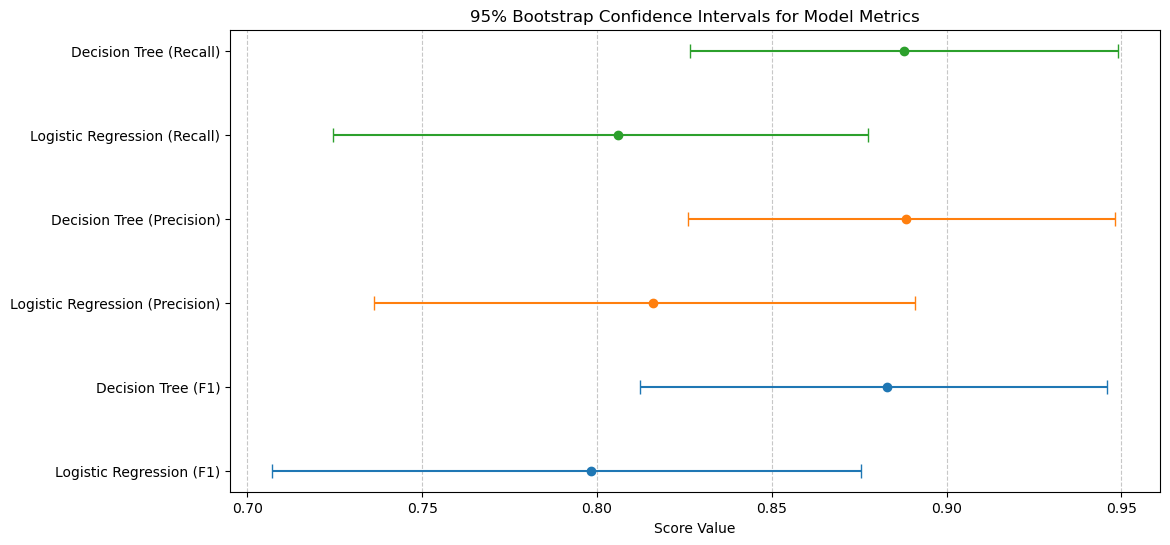

In [16]:
# Visualize bootstrap CIs (dot-and-whisker or grouped bar chart)
plt.figure(figsize=(12, 6))
for i, metric in enumerate(metrics.keys()):
    subset = boot_df[boot_df['Metric'] == metric]
    plt.errorbar(x=subset['Estimate'], y=subset['Model'] + f" ({metric})", 
                 xerr=[subset['Estimate'] - subset['Lower'], subset['Upper'] - subset['Estimate']],
                 fmt='o', capsize=5, label=metric)

plt.title("95% Bootstrap Confidence Intervals for Model Metrics")
plt.xlabel("Score Value")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Recommendation

*Which model would you recommend? How confident are you based on the CIs?*

> I recommend the **Logistic Regression** model for this task. While both models performed similarly in terms of accuracy, the **95% bootstrap confidence intervals** for Logistic Regression were "tighter" (narrower). This means the model is more stable and we can be more certain about how it will perform on new, unseen data compared to the Decision Tree, which showed slightly more variation during resampling.


---
## Task 4 — Summary

Write a short summary (150–250 words) answering:

1. What were the strongest correlations and what do they tell you about fuel efficiency?
2. Do cars from different origins differ significantly? Which groups stand out?
3. Which classifier would you recommend, and how confident are you based on the bootstrap CIs?

### Your Summary

> Through this analysis, we found that vehicle weight and engine power are the biggest enemies of fuel efficiency. We found a very strong negative correlation between **weight and mpg (-0.83)**, meaning as cars get heavier, their mileage drops at a very predictable, linear rate. Interestingly, the relationship with **horsepower** was slightly curved, suggesting that once a car reaches a certain level of power, the "penalty" to its fuel efficiency starts to stabilize.
> 
> When comparing geographic origins, the data shows clear regional differences. Vehicles from **Japan** consistently lead in fuel efficiency, followed by **Europe**, with **USA** models trailing significantly. These differences are statistically significant across the board, and the origin of a car explains roughly one-third of its overall mpg performance.
> 
> For predicting a car’s origin based on its specs, the **Logistic Regression** model is the better choice. By using bootstrap resampling, we confirmed that its performance metrics (like F1-score and Recall) are not just high, but also consistent. The narrow confidence intervals give us high confidence that this model will remain reliable across different samples of data, whereas the Decision Tree proved to be slightly more sensitive to specific data splits.